In [156]:
#1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()


In [157]:
#2. Load Dataset

df = pd.read_csv("customers.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [158]:
#3. Dataset understanding
print("\n===== DATASET OVERVIEW =====")

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
print(df.info())


===== DATASET OVERVIEW =====
Number of Rows : 8000
Number of Columns : 20

Columns:
['customer_id', 'country', 'age', 'gender', 'membership_tier', 'registration_date', 'total_orders', 'total_spend_usd', 'avg_order_value_usd', 'days_since_last_purchase', 'preferred_category', 'preferred_device', 'preferred_payment_method', 'acquisition_channel', 'reviews_given', 'avg_review_score', 'returns_made', 'wishlist_items', 'newsletter_subscribed', 'churned']

Data Types:
customer_id                  object
country                      object
age                           int64
gender                       object
membership_tier              object
registration_date            object
total_orders                  int64
total_spend_usd             float64
avg_order_value_usd         float64
days_since_last_purchase      int64
preferred_category           object
preferred_device             object
preferred_payment_method     object
acquisition_channel          object
reviews_given               

In [159]:

numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

overview = pd.DataFrame({
    "Item":[
        "Number of Rows",
        "Number of Columns",
        "Numerical Columns",
        "Categorical Columns"
    ],
    "Value":[
        df.shape[0],
        df.shape[1],
        len(numerical_cols),
        len(categorical_cols)
    ]
})

print(overview)

                  Item  Value
0       Number of Rows   8000
1    Number of Columns     20
2    Numerical Columns     11
3  Categorical Columns      9


In [160]:
#4. Data Cleaning
#Missing Values
print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

missing_percent = (df.isnull().sum()/len(df))*100
print("\nMissing Percentage:")
print(missing_percent)


===== MISSING VALUES =====
customer_id                 0
country                     0
age                         0
gender                      0
membership_tier             0
registration_date           0
total_orders                0
total_spend_usd             0
avg_order_value_usd         0
days_since_last_purchase    0
preferred_category          0
preferred_device            0
preferred_payment_method    0
acquisition_channel         0
reviews_given               0
avg_review_score            0
returns_made                0
wishlist_items              0
newsletter_subscribed       0
churned                     0
dtype: int64

Missing Percentage:
customer_id                 0.0
country                     0.0
age                         0.0
gender                      0.0
membership_tier             0.0
registration_date           0.0
total_orders                0.0
total_spend_usd             0.0
avg_order_value_usd         0.0
days_since_last_purchase    0.0
preferred_category

In [161]:
#Handle Missing Values
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_4276/2945410937.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_4276/2945410937.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [162]:
#Duplicate Records
print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Rows After Removing Duplicates:", df.shape[0])


Duplicate Rows: 0
Rows After Removing Duplicates: 8000


In [163]:
#Wrong Data Types
print("\nData Types Before Conversion")
print(df.dtypes)


Data Types Before Conversion
customer_id                  object
country                      object
age                           int64
gender                       object
membership_tier              object
registration_date            object
total_orders                  int64
total_spend_usd             float64
avg_order_value_usd         float64
days_since_last_purchase      int64
preferred_category           object
preferred_device             object
preferred_payment_method     object
acquisition_channel          object
reviews_given                 int64
avg_review_score            float64
returns_made                  int64
wishlist_items                int64
newsletter_subscribed         int64
churned                       int64
dtype: object


In [164]:
#Remove Unnecessary Columns
id_columns = [col for col in df.columns if "id" in col.lower()]

print("Possible ID Columns:", id_columns)

df.drop(columns=id_columns, inplace=True, errors="ignore")

Possible ID Columns: ['customer_id']


In [165]:
#5. Outlier Detection (IQR Method)
print("\n===== OUTLIER ANALYSIS =====")

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} Outliers")


===== OUTLIER ANALYSIS =====
age: 23 Outliers
total_orders: 313 Outliers
total_spend_usd: 619 Outliers
avg_order_value_usd: 477 Outliers
days_since_last_purchase: 351 Outliers
reviews_given: 302 Outliers
avg_review_score: 123 Outliers
returns_made: 888 Outliers
wishlist_items: 478 Outliers
newsletter_subscribed: 0 Outliers
churned: 715 Outliers


In [166]:
#6. Descriptive Statistics
print("\n===== NUMERICAL ANALYSIS =====")

stats = df.describe().T

stats["Median"] = df.median(numeric_only=True)

print(stats[["mean","Median","std","min","max"]])


===== NUMERICAL ANALYSIS =====
                                 mean  Median          std    min       max
age                         35.616375   35.00    11.170455  18.00     75.00
total_orders                16.545250   12.00    14.681064   1.00     79.00
total_spend_usd           1558.642350  845.70  2284.094953   4.89  61282.48
avg_order_value_usd         94.845566   72.27    78.992885   5.00   1051.73
days_since_last_purchase    59.583875   41.00    60.610355   0.00    582.00
reviews_given                3.228750    2.00     3.942698   0.00     28.00
avg_review_score             4.109112    4.20     0.523992   1.80      5.00
returns_made                 0.849500    0.00     1.407337   0.00     11.00
wishlist_items               4.457125    3.00     4.854391   0.00     41.00
newsletter_subscribed        0.617375    1.00     0.486058   0.00      1.00
churned                      0.089375    0.00     0.285302   0.00      1.00


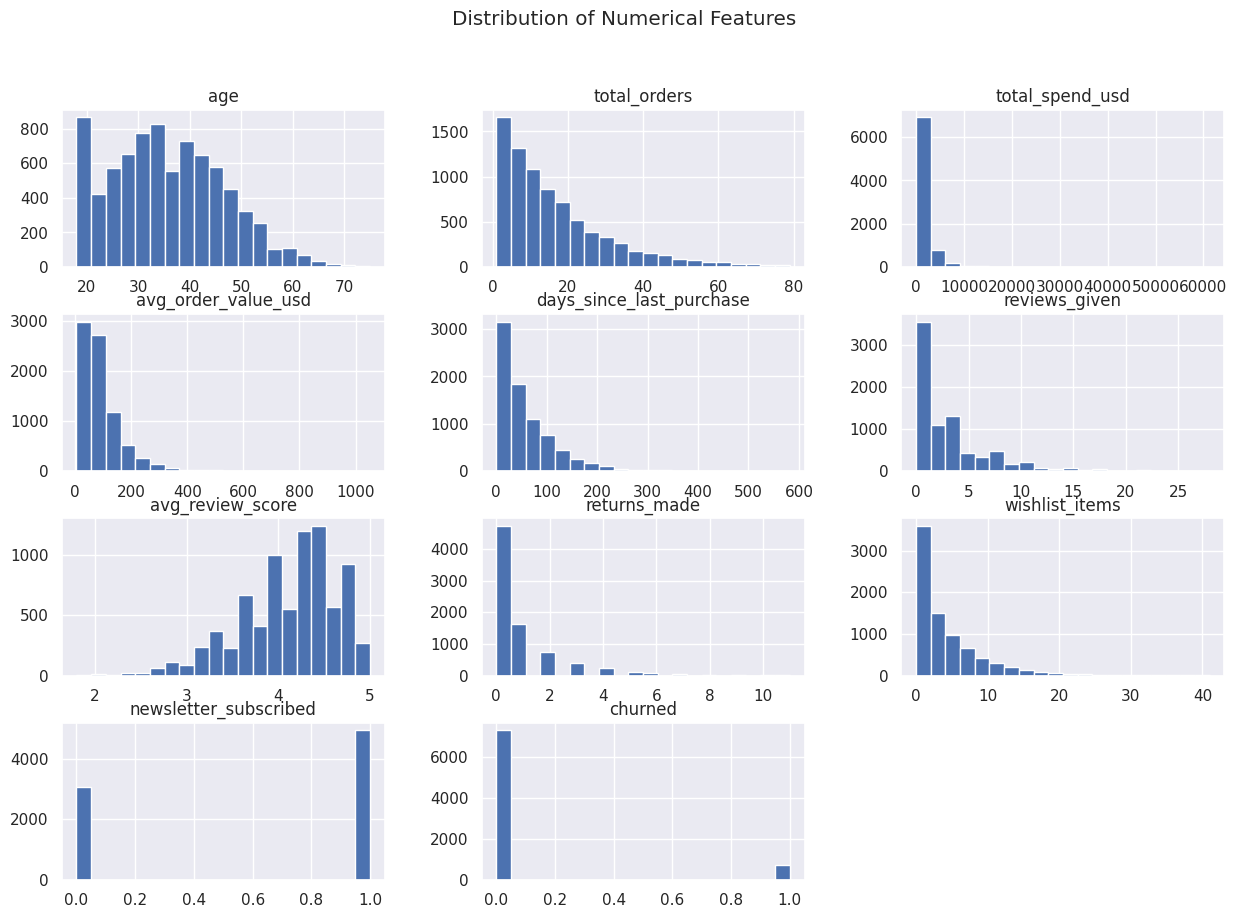

In [167]:
#7. Univariate Analysis
df[numerical_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.suptitle("Distribution of Numerical Features")
plt.show()

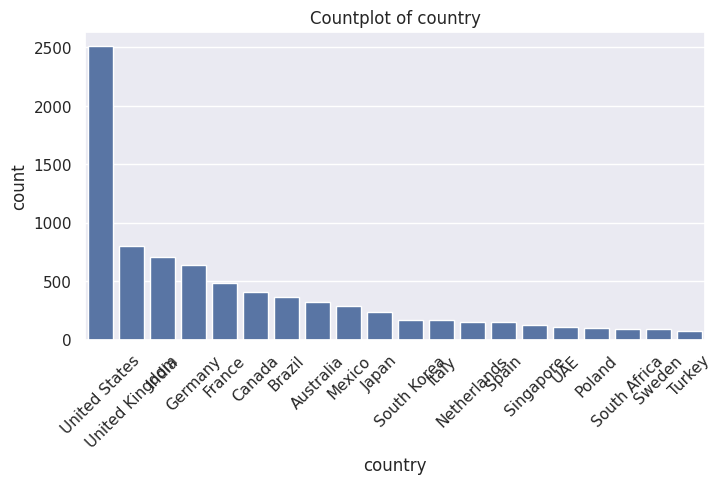

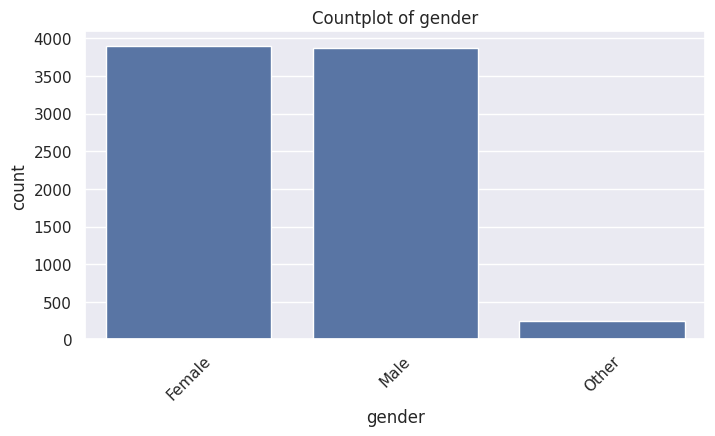

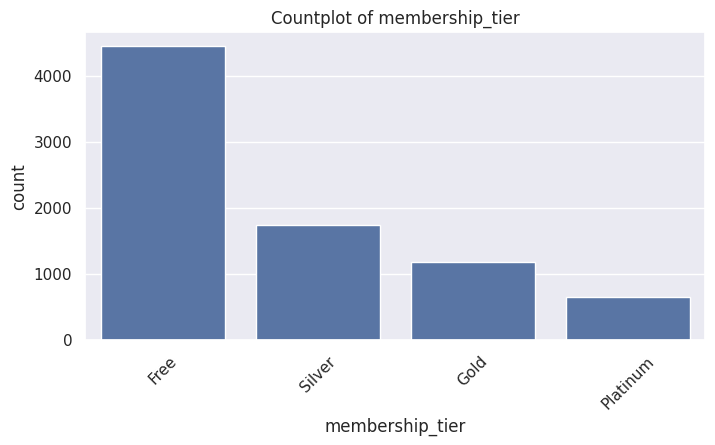

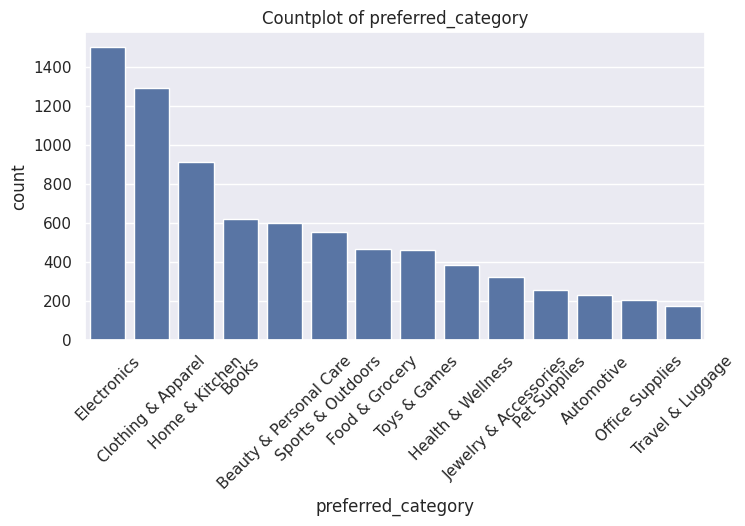

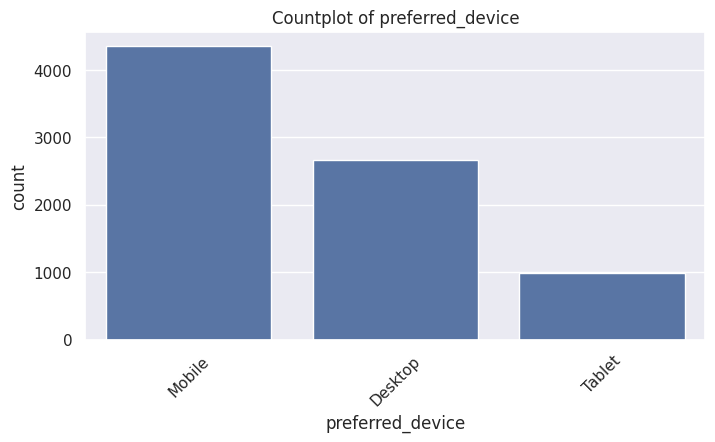

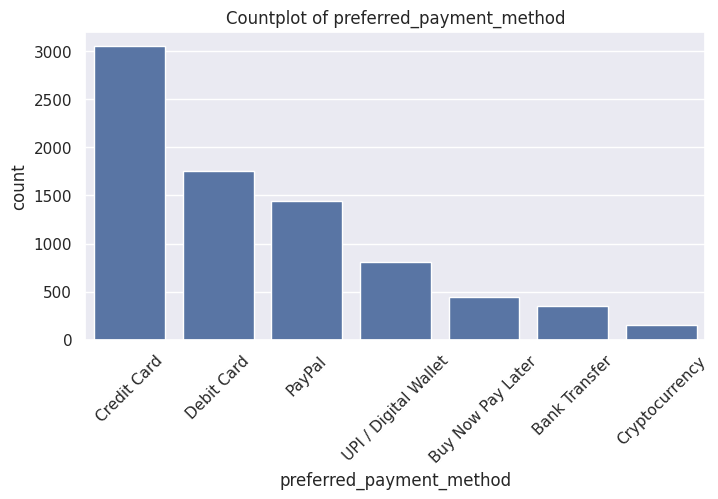

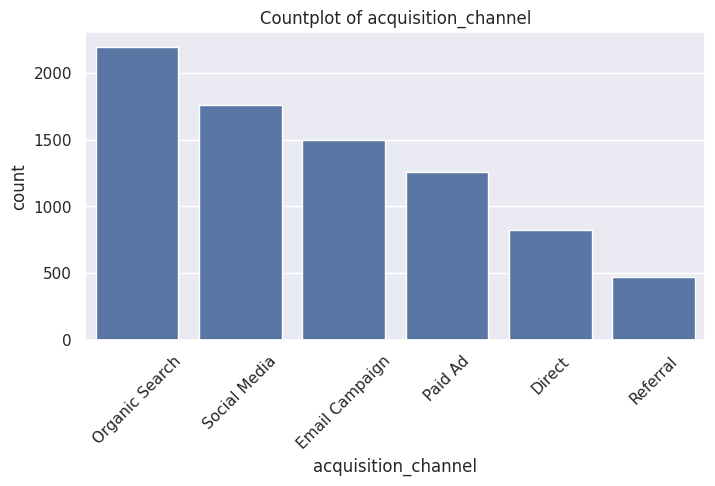

In [168]:
#Categorical Features
# Redefine categorical_cols to reflect current state of df
categorical_cols = df.select_dtypes(include=['object']).columns

# Filter out 'registration_date' as it is a date and not suitable for countplots
categorical_cols_for_plot = [col for col in categorical_cols if col != 'registration_date']

for col in categorical_cols_for_plot:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.xticks(rotation=45)
    plt.title(f"Countplot of {col}")
    plt.show()

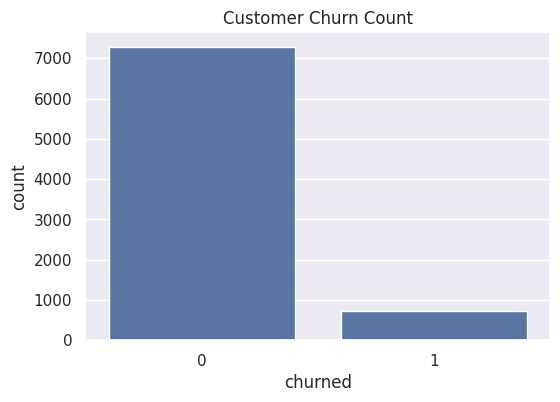

In [169]:
#8. Target Variable Analysis
target = "churned"
#Chart 1: Churn Count Plot
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x=target
)

plt.title("Customer Churn Count")
plt.show()

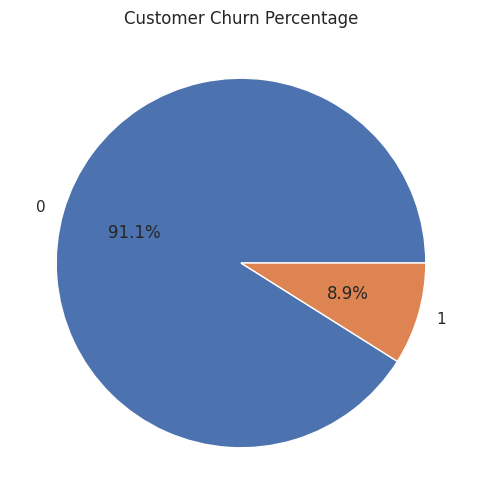

In [170]:
#Chart 2: Churn Percentage Pie Chart
df[target].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Customer Churn Percentage")
plt.show()

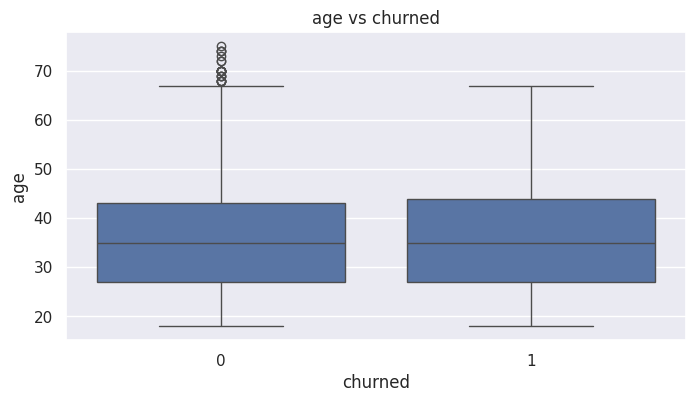

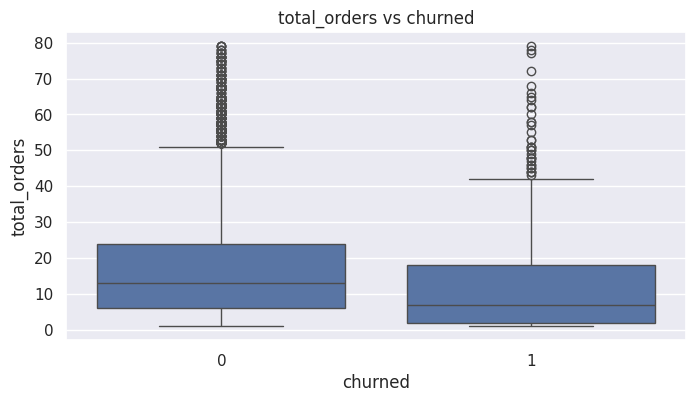

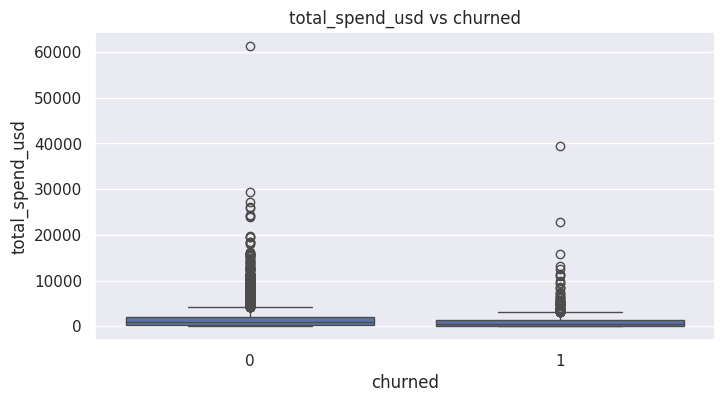

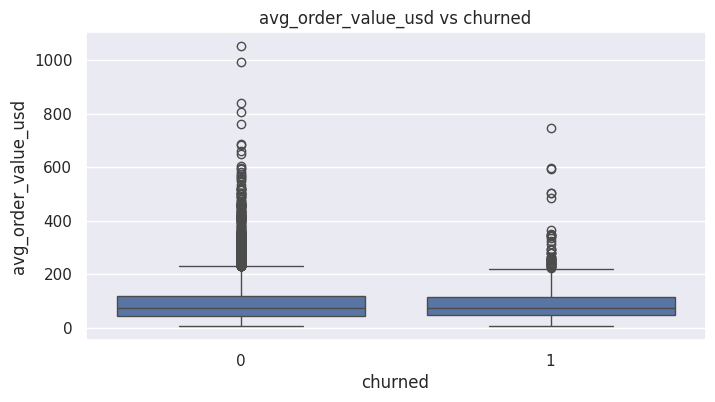

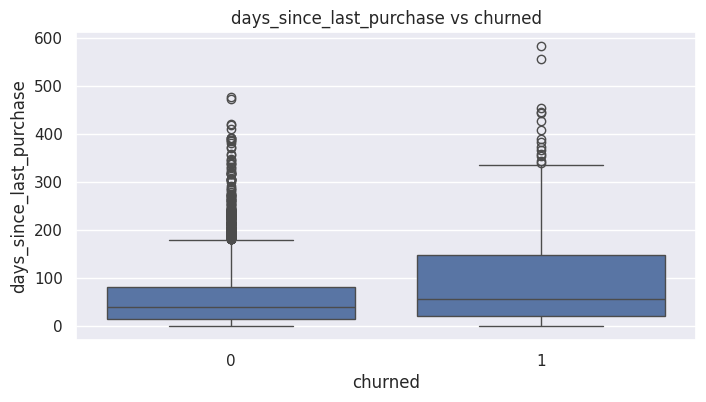

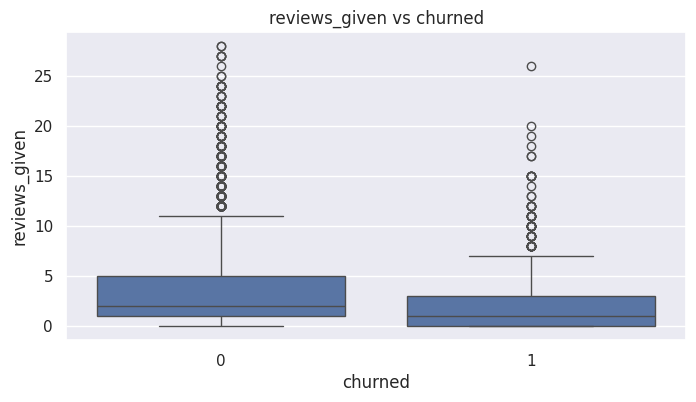

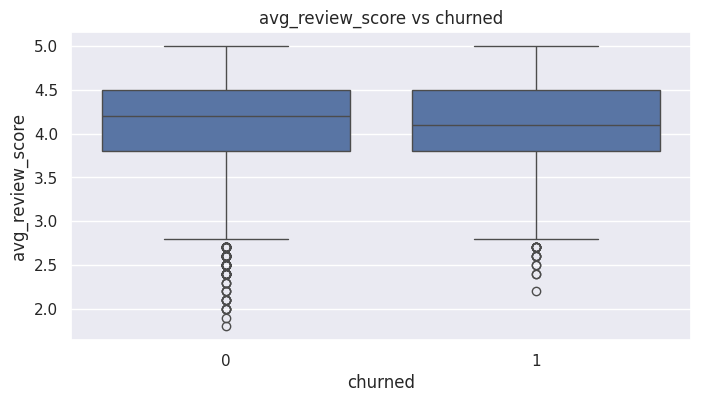

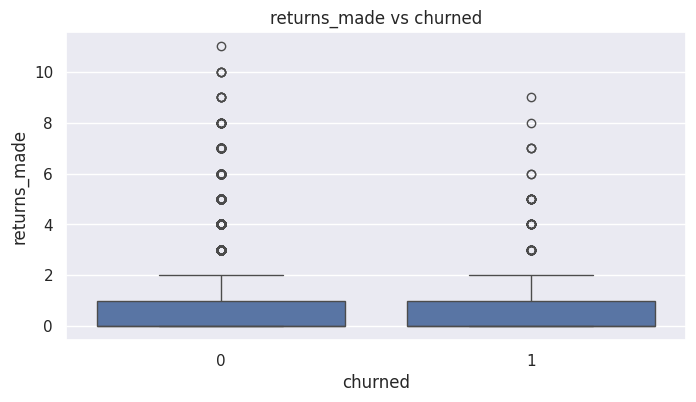

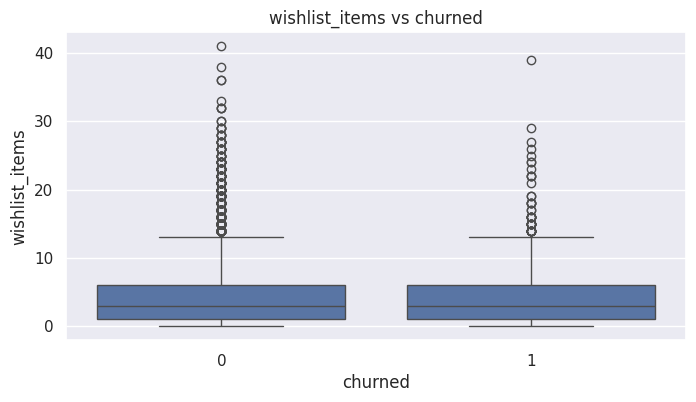

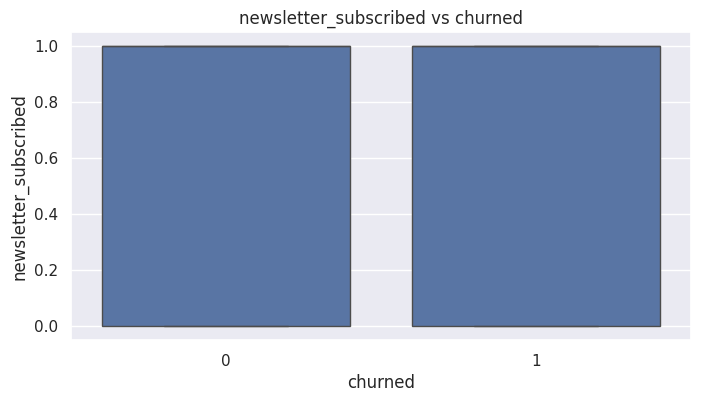

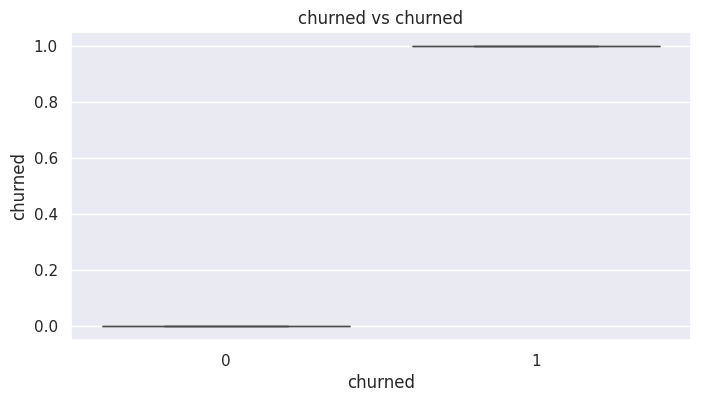

In [171]:
#9. Bivariate Analysis
#Numerical Features vs Churn
for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df,
        x=target,
        y=col
    )

    plt.title(f"{col} vs {target}")
    plt.show()

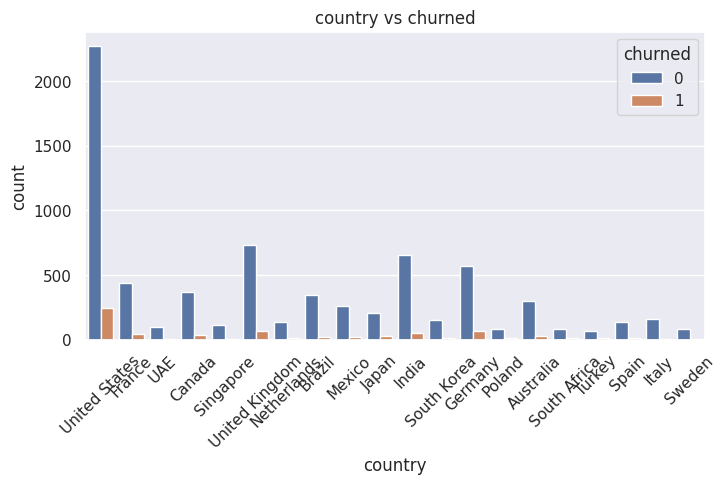

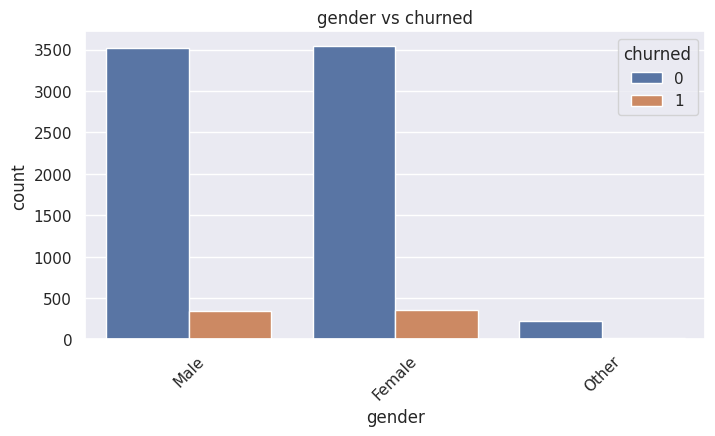

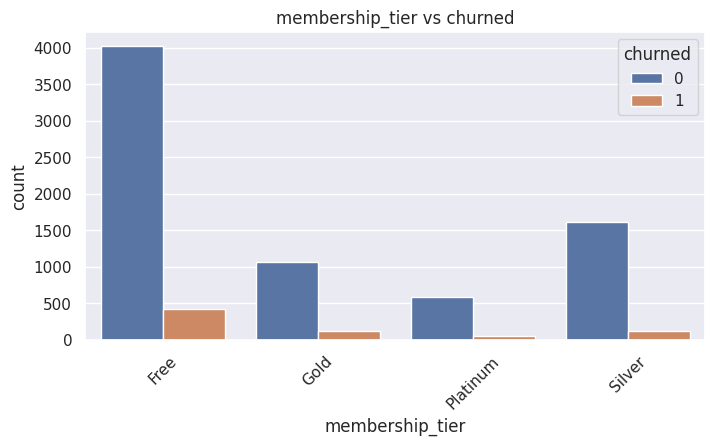

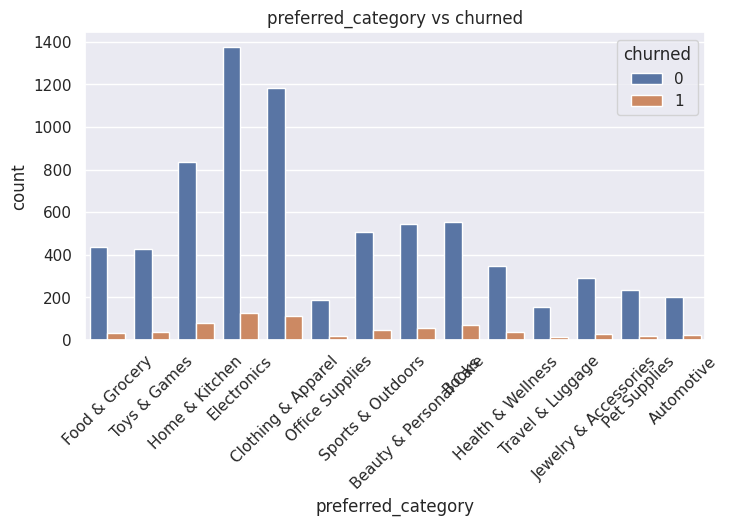

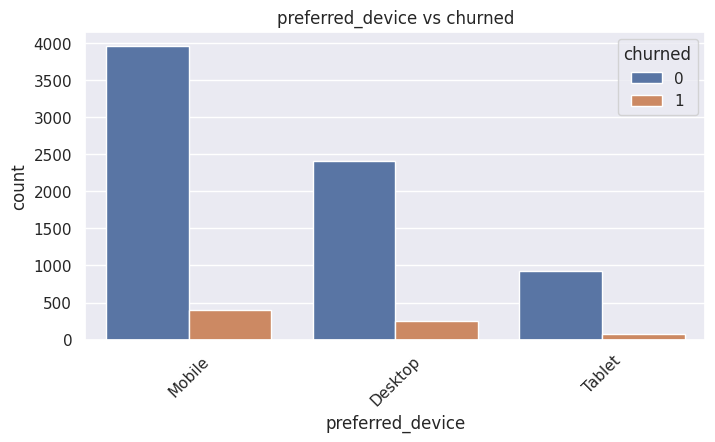

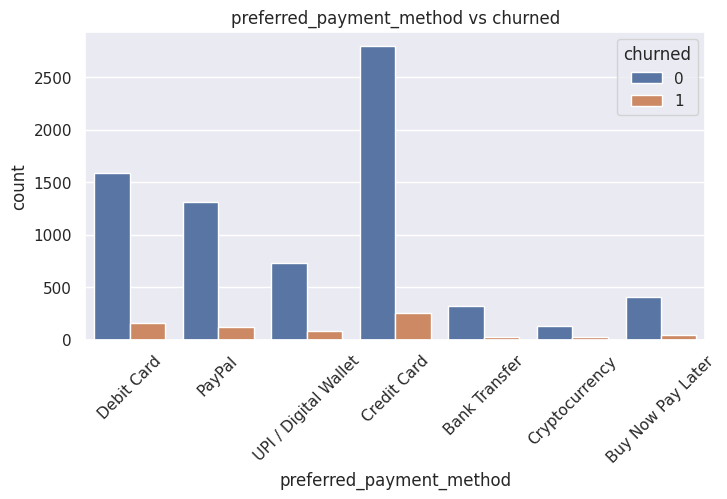

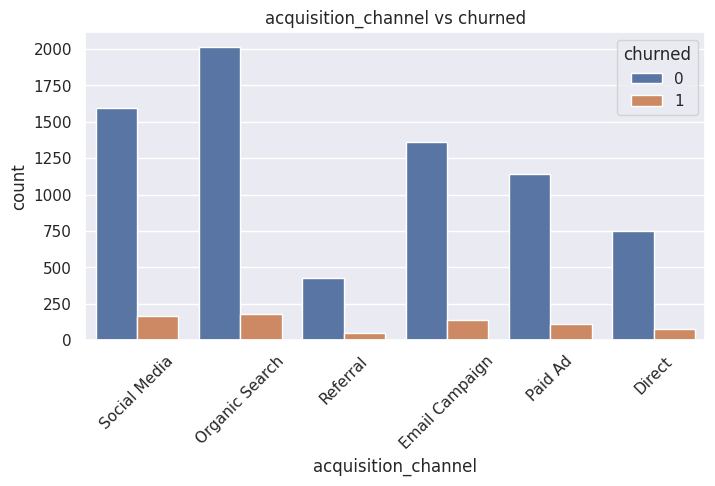

In [172]:
#Categorical Features vs Churn
# Redefine categorical_cols to reflect current state of df
categorical_cols = df.select_dtypes(include=['object']).columns

# Filter out 'registration_date' as it is a date and not suitable for countplots
categorical_cols_for_plot = [col for col in categorical_cols if col != 'registration_date']

for col in categorical_cols_for_plot:

    if col != target:

        plt.figure(figsize=(8,4))

        sns.countplot(
            data=df,
            x=col,
            hue=target
        )

        plt.xticks(rotation=45)
        plt.title(f"{col} vs {target}")

        plt.show()

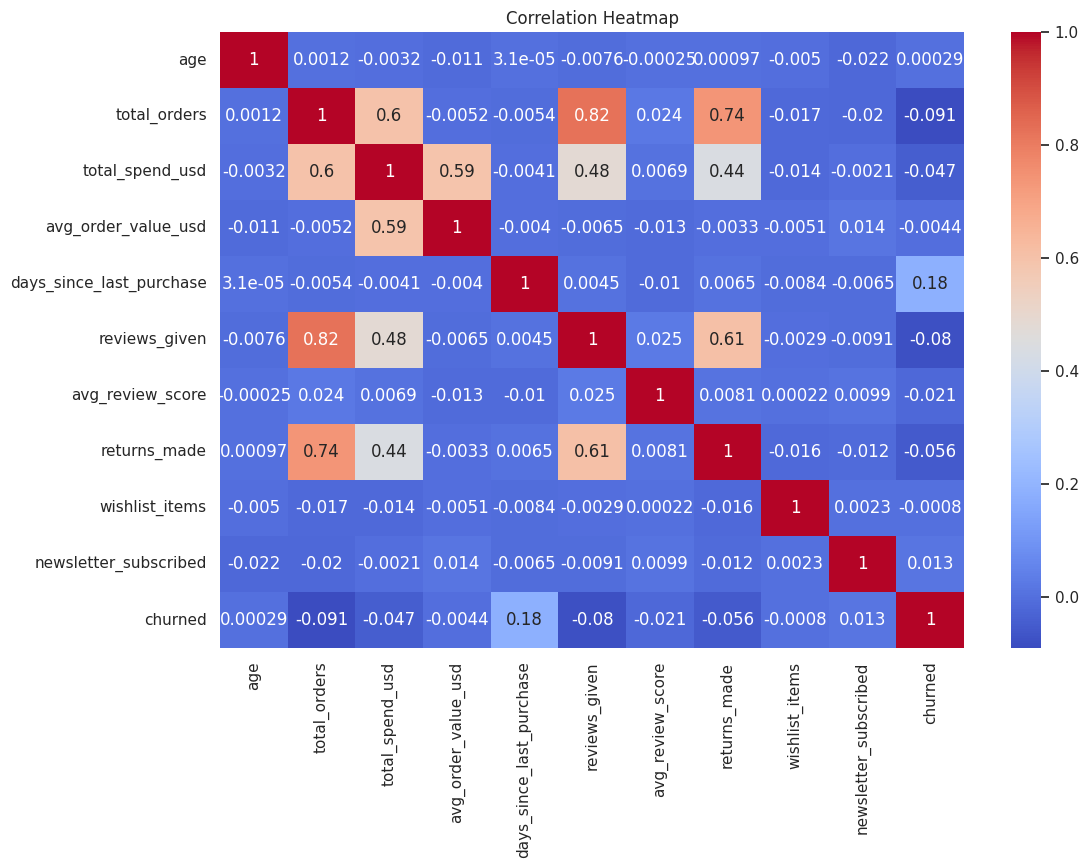

In [173]:
#10. Correlation Analysis
#Chart 3: Correlation Heatmap
plt.figure(figsize=(12,8))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

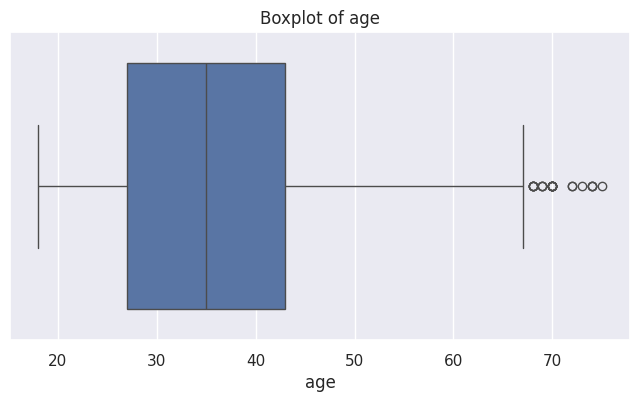

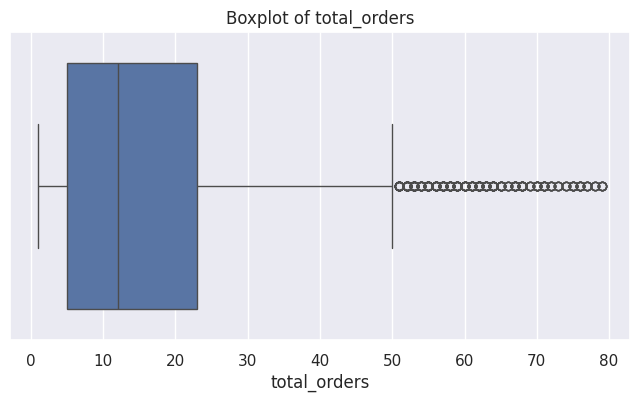

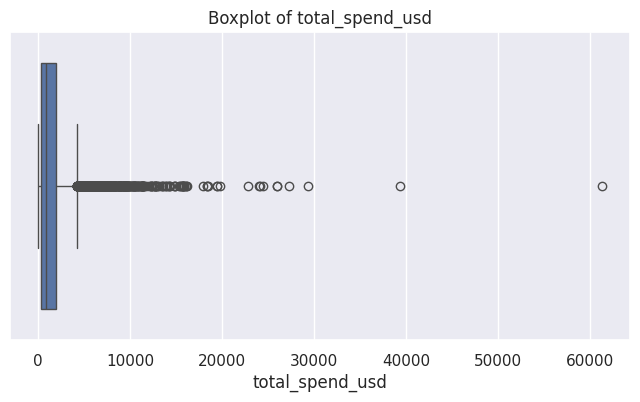

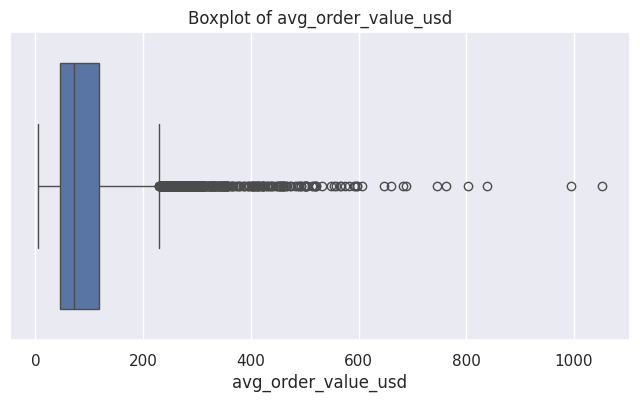

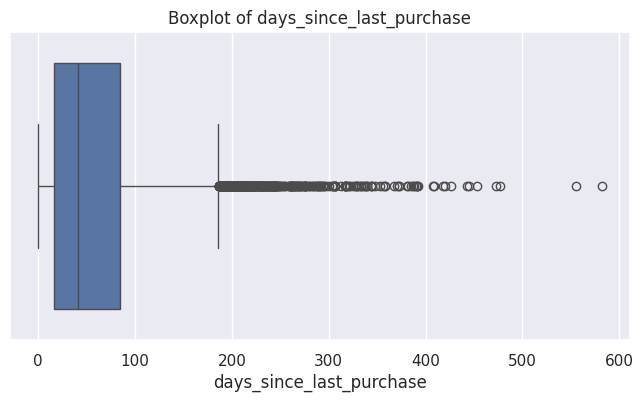

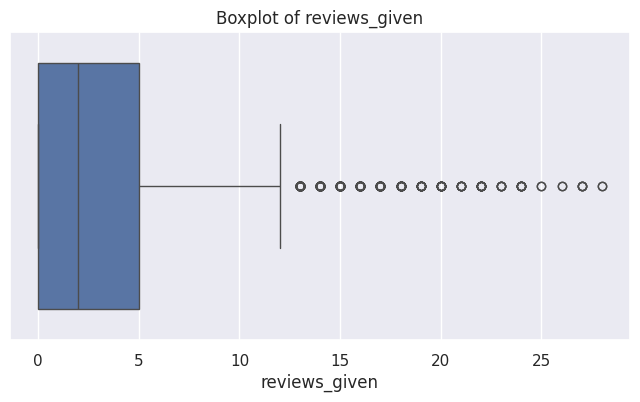

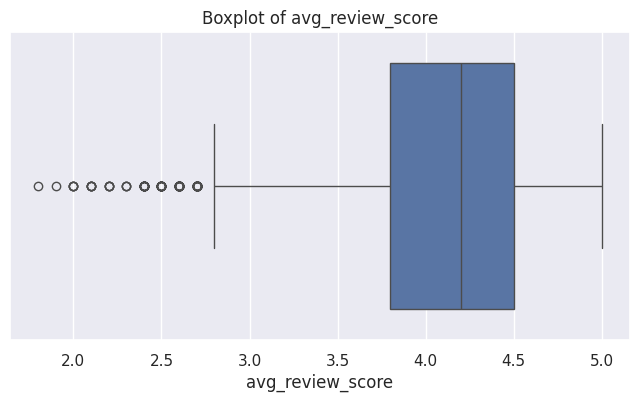

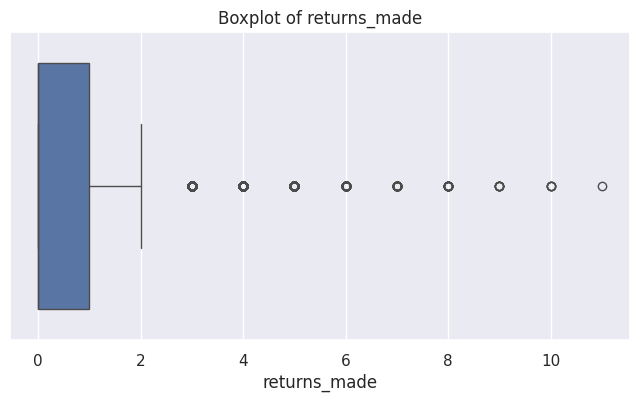

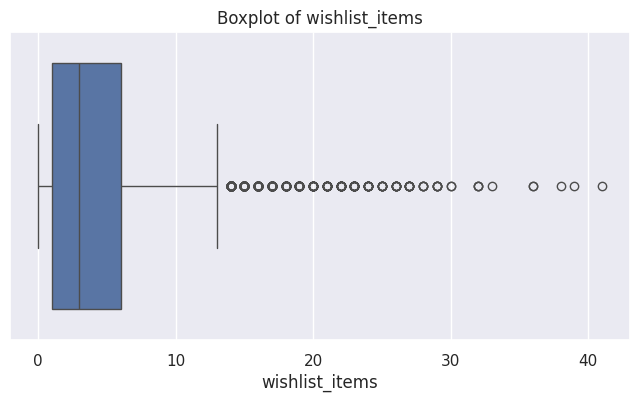

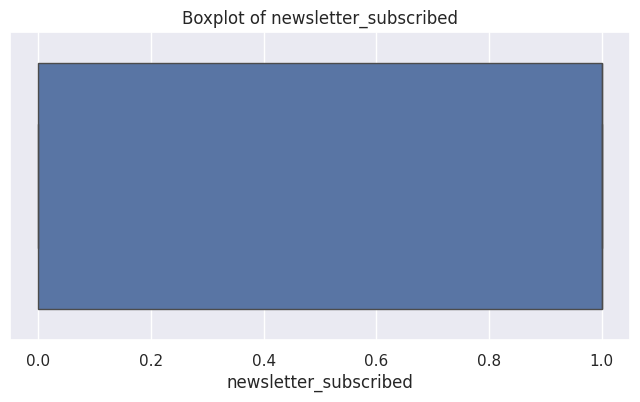

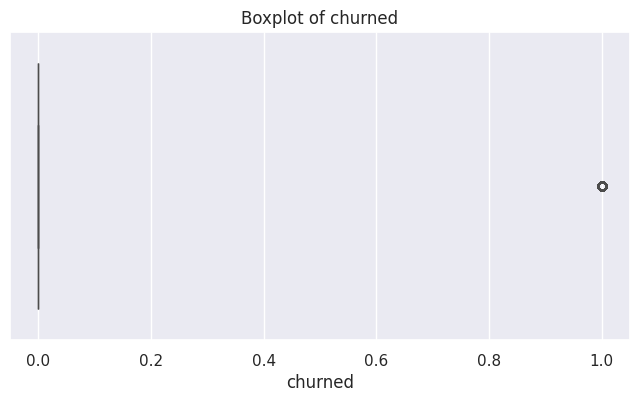

In [174]:
#11. Outlier Visualization
#Chart 4: Boxplots
for col in numerical_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

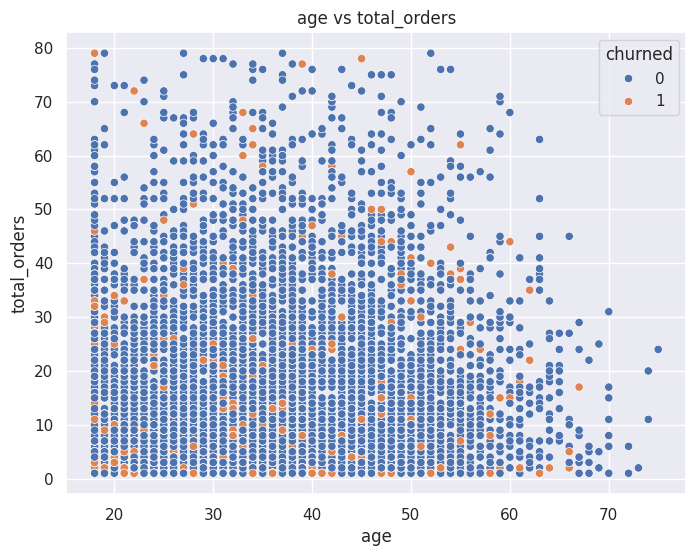

In [175]:
#12. Scatter Plot Analysis
#Chart 5: Scatter Plot
if len(numerical_cols) >= 2:

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=df,
        x=numerical_cols[0],
        y=numerical_cols[1],
        hue=target
    )

    plt.title(
        f"{numerical_cols[0]} vs {numerical_cols[1]}"
    )

    plt.show()

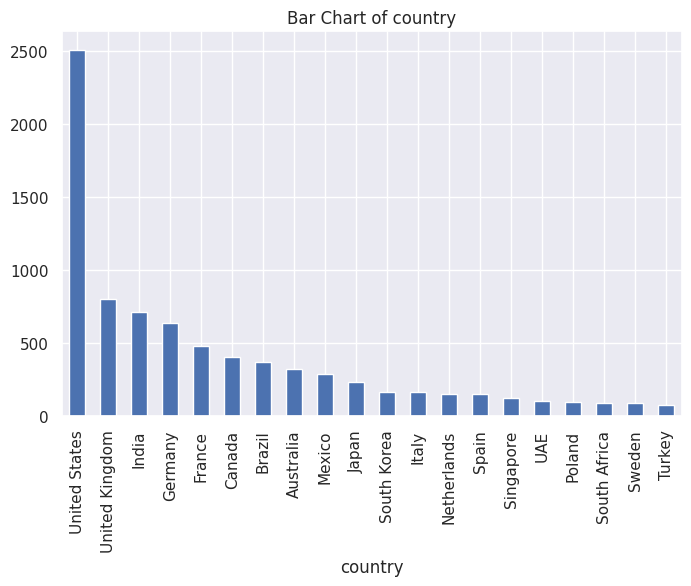

In [176]:
#Chart 6: Bar Chart
cat_col = categorical_cols[0]

df[cat_col].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(f"Bar Chart of {cat_col}")
plt.show()

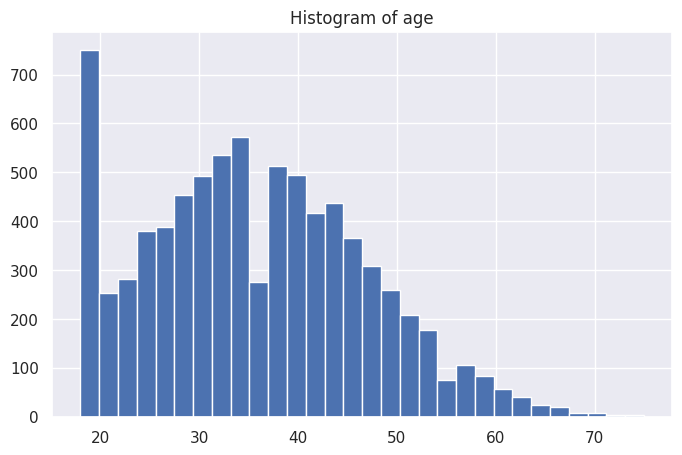

In [177]:
#Chart 7: Histogram
plt.figure(figsize=(8,5))

df[numerical_cols[0]].hist(
    bins=30
)

plt.title(f"Histogram of {numerical_cols[0]}")
plt.show()

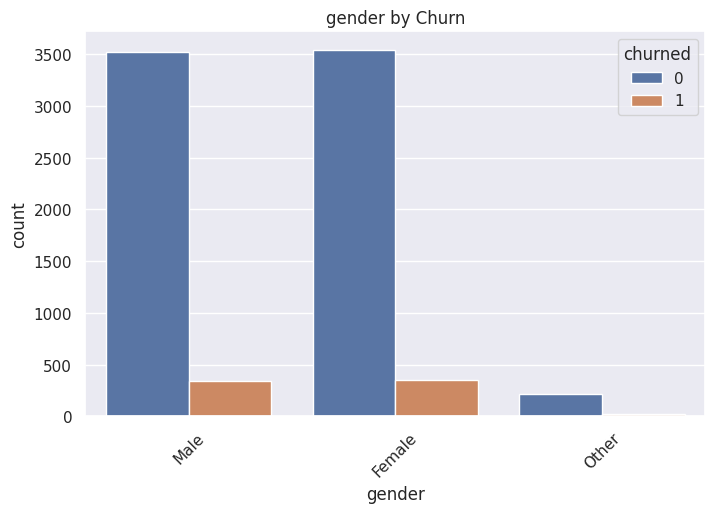

In [178]:
#Chart 8: Countplot with Churn
if len(categorical_cols) > 1:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x=categorical_cols[1],
        hue=target
    )

    plt.xticks(rotation=45)

    plt.title(
        f"{categorical_cols[1]} by Churn"
    )

    plt.show()

In [179]:
#13. Final Insights Section
print("===== FINAL INSIGHTS =====")

print("""
1. Churn distribution observed from countplot and pie chart.
2. Numerical features compared using boxplots.
3. Categorical features analyzed against churn.
4. Correlation heatmap shows relationships among numerical variables.
5. Outliers identified using IQR and boxplots.
6. Histograms reveal feature distributions.
7. Scatter plot shows interaction between numerical variables.
8. Data cleaned by handling missing values, duplicates, and inconsistencies.
""")

===== FINAL INSIGHTS =====

1. Churn distribution observed from countplot and pie chart.
2. Numerical features compared using boxplots.
3. Categorical features analyzed against churn.
4. Correlation heatmap shows relationships among numerical variables.
5. Outliers identified using IQR and boxplots.
6. Histograms reveal feature distributions.
7. Scatter plot shows interaction between numerical variables.
8. Data cleaned by handling missing values, duplicates, and inconsistencies.

